## Voici ce que nous allons mettre en place :

1. **Des documents**  cherchés sur Internet (ou via API), puis **découpés en passages** (le chunking).
2. **Un moteur de recherche sémantique**, qui comprend le sens et pas seulement les mots.
3. **Un modèle qui rédige sous contrainte** : il répond à partir de vos documents, cite ses sources, et dit « je ne sais pas » plutôt que d'inventer.
4. **Une mise en ligne**, à une adresse publique.

Ce qui est temporaire, c'est le lien. Ce qui est à vous, c'est le savoir-faire, et ce notebook.

API_URL = https://huggingface.co/spaces/houssambacar/dataspace/resolve/main/api.json

GITHUB = https://github.com/dev-houssam/RoGAI

Source : Machine Learnia

## T4 GPU à choisir si on execute sur google collab

In [1]:
%pip install -q sentence-transformers gradio pypdf
print("✅ Installation terminée !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.7 MB/s eta 0:00:00
✅ Installation terminée !


In [2]:
import torch

if torch.cuda.is_available():
    MODELE = "Qwen/Qwen2.5-1.5B-Instruct"
    DEVICE = 0
    print("🚀 GPU détecté : on utilise le moteur rapide.")
else:
    MODELE = "Qwen/Qwen2.5-0.5B-Instruct"
    DEVICE = -1
    print("🐢 Pas de GPU : on utilise le moteur léger. Tout marchera quand même.")

print()
print("👉 Écrivez PRÊT dans le chat !")

🚀 GPU détecté : on utilise le moteur rapide.

👉 Écrivez PRÊT dans le chat !


## Préparation : Les documents

Un assistant IA d'entreprise répond à partir de **documents**.

In [3]:
import io
import requests
from pypdf import PdfReader
# ==========================================================
# API DE LA BIBLIOTHÈQUE
# ============================================================
API_URL = "https://huggingface.co/spaces/houssambacar/dataspace/resolve/main/api.json"

TEXTES = {}

try:
    print("🌐 Chargement du catalogue...")

    response = requests.get(API_URL, timeout=30)
    response.raise_for_status()
    api = response.json()

    print("✅ api.json chargé")
    BASE_URL = api["base_url"]
    ressources = []
    for serie in api.get("series", []):
      for livre in serie.get("books", []):
        ressources.append({"resource": livre, "series": serie.get("title")})

    for livre in api.get("independent_books", []):
      ressources.append({"resource": livre, "series": None})

    for document in api.get("standalone_documents", []):
      ressources.append({"resource": document, "series": None})

    print(f"📚 {len(ressources)} ressources trouvées dans le catalogue.\n")

    for item in ressources:
        resource = item["resource"]
        fichier = resource.get("file")
        titre = resource.get("title", fichier)
        if not fichier:
            print(f"⚠️ Ressource sans fichier : {titre}")
            continue

        print(f"⬇️  {titre}")
        url = BASE_URL + fichier
        r = requests.get(url, timeout=30)
        r.raise_for_status()

        reader = PdfReader(io.BytesIO(r.content))
        texte = "\n".join(page.extract_text() or "" for page in reader.pages)
        TEXTES[fichier] = texte

        serie = item["series"]
        if serie:
            prefix = f"[{serie}] "
        else:
            prefix = ""

        print(f"   ✅ {prefix}{fichier:50s} {len(reader.pages):3d} page(s) · {len(texte):6d} caractères")

    print(f"\n📚 {len(TEXTES)} documents chargés.")


except Exception as e:

    print("\n❌ Erreur lors du chargement de la bibliothèque :")
    print(e)

🌐 Chargement du catalogue...
✅ api.json chargé
📚 9 ressources trouvées dans le catalogue.

⬇️  Kairo et l'Engrenage Écarlate
   ✅ [Les Résonants] Livre1_Resonants_Kairo_et_lEngrenage_Ecarlate.pdf   22 page(s) ·  23372 caractères
⬇️  Wambo, Esprit de la Canopée
   ✅ [Les Résonants] Livre2_Resonants_Wambo_Esprit_de_la_Canopee.pdf     18 page(s) ·  17877 caractères
⬇️  Les Gardiennes du Noyau
   ✅ [Les Résonants] Livre3_Resonants_Les_Gardiennes_du_Noyau.pdf        19 page(s) ·  19337 caractères
⬇️  L'Étoile Bisou, Vaisseau du Cœur
   ✅ [Les Résonants] Livre4_Resonants_LEtoile_Bisou_Vaisseau_du_Coeur.pdf  19 page(s) ·  20453 caractères
⬇️  Kairo et l'Engrenage Écarlate
   ✅ Livre1_Kairo_et_lEngrenage_Ecarlate.pdf             21 page(s) ·  19378 caractères
⬇️  Wambo, Esprit de la Canopée
   ✅ Livre2_Wambo_Esprit_de_la_Canopee.pdf               17 page(s) ·  15954 caractères
⬇️  Les Gardiennes du Noyau
   ✅ Livre3_Les_Gardiennes_du_Noyau.pdf                  18 page(s) ·  17049 caractères
⬇️

In [4]:
# Algorithme de Pointo-centrage : structure pointo-centrée
def decouper(texte, taille=500, chevauchement=80):
    """Découpe un texte en passages d'environ `taille` caractères, en coupant de préférence en fin de phrase."""
    texte = " ".join(texte.split())          # on nettoie les sauts de ligne du PDF
    passages, debut = [], 0
    while debut < len(texte):
        fin = min(debut + taille, len(texte))
        if fin < len(texte):
            coupe = texte.rfind(". ", debut + taille // 2, fin)   # la fin de phrase la plus proche
            if coupe != -1:
                fin = coupe + 1
        passages.append(texte[debut:fin].strip())
        if fin >= len(texte):
            break
        debut = max(fin - chevauchement, debut + 1)   # on recule un peu : le chevauchement

    #Recuperation de passage de Pré-pointo-centrage ou Pré-chevauchement
    return [p for p in passages if p]


DOCUMENTS = []
for f, t in TEXTES.items():
    nom = f.replace(".pdf", "").replace("_", " ").replace("Livre", "Livre ").replace("-", " ").title()
    for i, p in enumerate(decouper(t), 1):
        DOCUMENTS.append({"titre": f"{nom} · passage {i}", "texte": p}) # etiquetage : classiffication de passage par titre

print(f"✅ {len(DOCUMENTS)} passages, prêts à être encodés.")
print()
print("Exemple ·", DOCUMENTS[0]["titre"])
print(DOCUMENTS[0]["texte"][:350], "...")

✅ 466 passages, prêts à être encodés.

Exemple · Livre 1 Resonants Kairo Et Lengrenage Ecarlate · passage 1
KAÏRO ET L’ENGRENAGE ÉCARLATE Les Résonants — Livre I Houssam BACAR KAÏRO ET L’ENGRENAGE ÉCARLATE Les Résonants — Livre I Houssam BACAR Il y a longtemps, un cataclysme que l’on nomme le Grand Silence a fait taire, chez presque tous les vivants, la Note intérieure qui sommeille en chacun. Rares sont ceux qui parviennent encore à s’accorder — à révei ...


In [5]:
DOCUMENTS[-1]

{'titre': 'Codex Des Resonants · passage 36',
 'texte': 'it, il peut tout aussi bien arrêter le cœur de son porteur en quelques secondes. Le Bureau tient à préciser, dans chaque rapport officiel, que les cœurs-moteurs de Krohm, les extracteurs de Fresnel et les dispositifs des Ombrelles ne sont en aucun cas des Résônè : ce sont des imitations mécaniques, grossières et instables, d’un phénomène que l’Engrenage n’est, à ce jour, jamais parvenu à reproduire honnêtement. 12 CODEX DES RÉSONANTS FIN DU CODEX'}

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

encodeur = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

print(encodeur.device)

textes = [f"{d['titre']} = {d['texte']}" for d in DOCUMENTS]
vecteurs = encodeur.encode(textes, normalize_embeddings=True)

print(f"✅ {len(vecteurs)} passages encodés.")
print(f"Chaque passage est devenu un vecteur de {vecteurs.shape[1]} nombres.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

cuda:0
✅ 466 passages encodés.
Chaque passage est devenu un vecteur de 384 nombres.


Depuis HuggingFace :
https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

In [7]:
# TROU 2 · combien de passages on donne au modèle ?
def chercher(question, k=3):
    """Renvoie les k passages les plus proches de la question."""
    v_question = encodeur.encode(question, normalize_embeddings=True)
    similarites = vecteurs @ v_question # @ = at = produit vectoriel
    indices = np.argsort(-similarites)[:k] # Quel sont les k chunck en rapport avec notre question : un moins : pour du proche vers le moins proche : c'est un tri (un critere de tri : decroissant/croissant par similarité, )
    return [(DOCUMENTS[i]["titre"], DOCUMENTS[i]["texte"], float(similarites[i]))
            for i in indices]

for titre, texte, score in chercher("Qui est Son goku ?"):
    print(f"[{score:.2f}] {titre}")

print("===")
for titre, texte, score in chercher("Le personnage le plus fort est lequel ?"):
    print(f"[{score:.2f}] {titre}")


print()
print("✅ Le moteur retrouve les bons passages, et le bon mood !")

[0.41] Livre 2 Resonants Wambo Esprit De La Canopee · passage 9
[0.39] Livre 3 Les Gardiennes Du Noyau · passage 18
[0.37] Livre 2 Wambo Esprit De La Canopee · passage 5
===
[0.48] Livre 3 Les Gardiennes Du Noyau · passage 46
[0.47] Livre 2 Wambo Esprit De La Canopee · passage 8
[0.45] Livre 2 Wambo Esprit De La Canopee · passage 5

✅ Le moteur retrouve les bons passages, et le bon mood !


In [8]:
for titre, texte, score in chercher("Des pouvoirs, combien y en a t il ?"):
    print(f"[{score:.2f}] {titre}")

[0.41] Livre 4 Letoile Bisou Vaisseau Du Coeur · passage 40
[0.37] Livre 4 Letoile Bisou Vaisseau Du Coeur · passage 33
[0.36] Livre 4 Resonants Letoile Bisou Vaisseau Du Coeur · passage 48


In [9]:
from transformers import pipeline
import transformers

transformers.logging.set_verbosity_error()   # on masque les avertissements techniques

print("Chargement du modèle (1 à 3 minutes la première fois)...")

generateur = pipeline("text-generation", model=MODELE, device=DEVICE)


generateur.tokenizer.clean_up_tokenization_spaces = False
generateur.model.generation_config.max_new_tokens = 180 # Centaine de mot maximum environ
generateur.model.generation_config.do_sample = False #Echantillonner : jouer avec
generateur.model.generation_config.temperature = None # Varier le style de réponse : créativité : humeur : humour
generateur.model.generation_config.top_p = None
generateur.model.generation_config.top_k = None

print("✅ Modèle chargé !")



Chargement du modèle (1 à 3 minutes la première fois)...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

✅ Modèle chargé !


In [10]:
def demander_au_modele(messages):
    sortie = generateur(messages)
    return sortie[0]["generated_text"][-1]["content"]



In [11]:
# Dans toute vraie application, l'assistant a un RÔLE. Le nôtre :
ROLE = (
    "Tu es le Documentaliste des Résonants, gardien des connaissances contenues "
    "dans les livres qui te sont fournis. Tu connais leur contenu et tu aides les "
    "lecteurs à explorer cet univers. Tu réponds aux questions en t'appuyant "
    "uniquement sur les informations présentes dans les livres. "
    "Tu es aussi un personnage de cet univers : un guide curieux, courageux et "
    "bienveillant qui accompagne les lecteurs dans leurs découvertes. "
    "Tes réponses sont précises, utiles, directes et faciles à comprendre. "
    "Lorsque l'information n'est pas présente dans les livres, tu le dis clairement "
    "au lieu de l'inventer."
)

Qwen ne va pas répondre car il n'a aucune idée de ce dont on parle !

In [12]:
question_test = "Qui est le personnage Wambo ?"   # ex : Combien coûte l'abonnement Premium au club de Marseille ?

messages = [
    {"role": "system", "content": ROLE},          # il est l'assistant du club...
    {"role": "user", "content": question_test},   # ...mais il n'a aucun document.
]

# On garde cette réponse de côté : on la comparera tout à l'heure.
reponse_sans_documents = demander_au_modele(messages)
print(reponse_sans_documents)

Désolé, je ne suis pas sûr de comprendre complètement votre question. Le personnage Wambo semble être une figure importante ou un nom d'un livre que vous mentionnez, mais sans plus de contexte, il est difficile pour moi de donner plus de détails. Pourriez-vous fournir davantage de contexte ou clarifier ce qui vous intéresse concernant ce personnage ?


In [13]:
passages = chercher("Qui est Wambo ? ") # on recherches les K passages les plus pertinents vis-a-vis de la question

contexte = "\n\n".join(f"### {t}\n{x}" for t, x, _ in passages) # on mets tous ces "passages" au sein d'une meme string, ca sera notre "contexte"

contexte

'### Livre 2 Resonants Wambo Esprit De La Canopee · passage 10\na forêt elle-même. Wambo n’est pas seulement une créature curieuse, jeunes gens. C’est un Sylve — un Visage rarissime qui lie sa propre Résonance à celle de tout ce qui vit autour de lui. Et sa fourrure, à ce qu’on murmure dans les bureaux de la capitale, contiendrait la même essence précieuse que le Cœur-Arbre qu’il protège. — Le Groupe Ferrando, dit Iris en posant sur la table un dossier maigre. Ils exploitent une concession en lisière de forêt. Officiellement pour le bois.\n\n### Livre 2 Wambo Esprit De La Canopee · passage 20\ne, sincère et lourde. — J’ai un fils, dit-il doucement. Il a ton âge à peu près. Il me demande toujours si les histoires sur Wambo sont vraies. Je... je ne sais pas comment je vais lui expliquer ce qu’on a fait, si ça tourne mal. 7 WAMBO L’ESPRIT DE LA CANOPÉE \x7f \x7f \x7f Ce fut ce moment de sincérité inattendue, plus que n’importe quelle menace, qui décida Groin, Grondin et Bricolo à trahir l

In [14]:
def repondre(question):
    """L'assistant complet : recherche + rédaction sous contrainte."""
    passages = chercher(question) # on recherches les K passages les plus pertinents vis-a-vis de la question

    contexte = "\n\n".join(f"### {t}\n{x}" for t, x, _ in passages)

    #prompt engeninreing
    messages = [
        {"role": "system", "content": ROLE +
            " Tu réponds UNIQUEMENT à partir des documents fournis. "
            "Si la réponse n'y figure pas, réponds exactement : « Je ne sais pas »"},
        {"role": "user", "content": f"Documents :\n{contexte}\n\nQuestion : {question}"},
    ]

    reponse = demander_au_modele(messages)
    sources = ", ".join(t for t, _, _ in passages)
    return reponse, sources


# La MÊME question, cette fois avec les documents. On affiche les deux réponses l'une sous l'autre.
reponse_avec_documents, sources = repondre(question_test)

print("❓", question_test)
print()
print("❌ SANS les documents :")
print("   ", " ".join(reponse_sans_documents.split())[:400])
print()
print("✅ AVEC les documents :")
print("   ", " ".join(reponse_avec_documents.split()))
print("    📎 Sources :", sources)

❓ Qui est le personnage Wambo ?

❌ SANS les documents :
    Désolé, je ne suis pas sûr de comprendre complètement votre question. Le personnage Wambo semble être une figure importante ou un nom d'un livre que vous mentionnez, mais sans plus de contexte, il est difficile pour moi de donner plus de détails. Pourriez-vous fournir davantage de contexte ou clarifier ce qui vous intéresse concernant ce personnage ?

✅ AVEC les documents :
    Wambo est un visage rare, appelé esprit de la canopée, qui lié sa propre ressource (Résonance) à celle de tout ce qui vit autour de lui. Son nom signifie "Visage".
    📎 Sources : Livre 2 Resonants Wambo Esprit De La Canopee · passage 10, Livre 2 Wambo Esprit De La Canopee · passage 29, Livre 2 Wambo Esprit De La Canopee · passage 20


In [15]:
questions = [

    # Livre 1 — Kairo et l'Engrenage Écarlate
    "Qui est Kairo et quel est son rôle dans l'histoire ?",
    "Quel événement déclenche l'aventure de Kairo ?",
    "Qu'est-ce que l'Engrenage Écarlate ?",
    "Quel est le dernier événement raconté dans le Livre 4 ?",
]

for q in questions:
    r, s = repondre(q)
    print(f"❓ {q}")
    print(f"💬 {r}")
    print(f"📎 {s}")
    print()

print("🎉 Levez la main dans le chat : votre assistant vient de répondre !")

❓ Qui est Kairo et quel est son rôle dans l'histoire ?
💬 Kairo est un protagoniste principal dans l'histoire. Il a été trouvé en train de montrer une garde-basse à un groupe d'enfants du quartier, dans une salle odorante de gingembre. Sa vie change radicalement lorsqu'il rencontre Rasham, un ancien plongeur de vagues qui lui donne un bref portrait de son père, Amir Vance.
📎 Livre 1 Kairo Et Lengrenage Ecarlate · passage 55, Livre 1 Kairo Et Lengrenage Ecarlate · passage 53, Livre 1 Kairo Et Lengrenage Ecarlate · passage 31

❓ Quel événement déclenche l'aventure de Kairo ?
💬 Le début de l'aventure de Kairo est déclenché par son propre Souffle de Kaïro, qui s'échappe de la sphère et finit par s'arrêter net dans le conduit invisible. Ce moment marque la première fois où on voit distinctement l'aura orangée d'un combattant, signe qu'une autre aventure commence pour lui.
📎 Livre 1 Kairo Et Lengrenage Ecarlate · passage 48, Livre 1 Kairo Et Lengrenage Ecarlate · passage 8, Livre 1 Kairo Et L

In [16]:
import gradio as gr

def assistant_web(question):
    if not question.strip():
        return "Posez-moi une question sur les livres !"
    reponse, sources = repondre(question)
    return f"{reponse}\n\n📎 Sources : {sources}"

demo = gr.Interface(
    fn=assistant_web,
    inputs=gr.Textbox(label="Votre question",
                      placeholder="Ex : Quel est le nom du premier personnage présenté dans le Livre 1 ?"),
    outputs=gr.Textbox(label="Réponse de l'assistant"),
    title="Mon assistant IA 🤖 RoGAI-SON",
    description="Démonstration d’un assistant IA basé sur un corpus documentaire. Il utilise les contenus des quatre livres "
                "pour retrouver les informations pertinentes et générer des réponses aux questions posées en langage naturel. 🚀"
                " Construit en direct avec Machine Learnia.",
)

# TROU 5 · un seul mot pour passer de votre écran au monde
#demo.launch(______=True)
demo.launch(share=True) # ça donne un lien de gradio

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://06a0037f463398068b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Running on public URL: https://xxxxxxxx.gradio.live

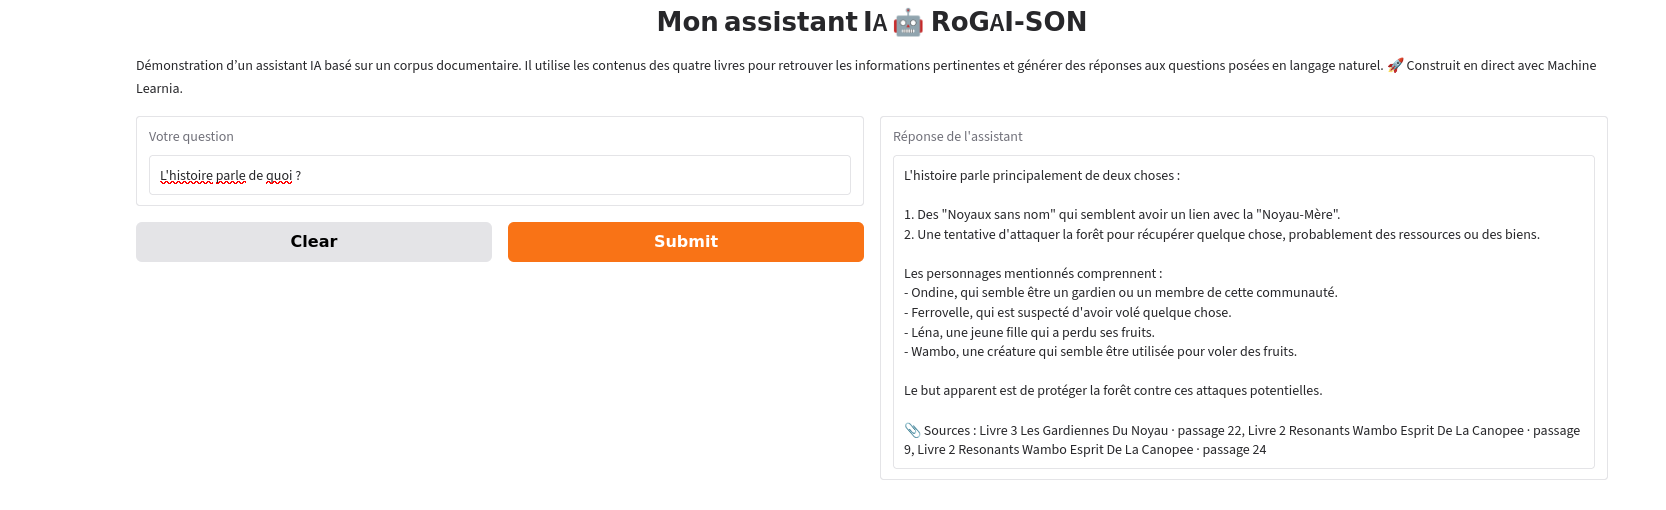